<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>   

<center>
  <h2 style="color:#000000";>Séance 3 : Equations différentielles (3)</h2>
</center>
<center>
  <h2 style="color:#000000";>Méthodes de Crank-Nicolson et Heun</h2>
</center>

## II - Résolution numérique des EDO (suite)

### 4) Schéma de Crank-Nicolson

Nous avons vu dans la séance précédente que les schémas d'Euler explicite et implicite étaient d'ordre 1. L'objectif est maintenant de construire des schémas d'ordre supérieur.

Reprenons une EDO générale de la forme : 

$$  (1) \ \ \displaystyle {{{\rm d}u}\over{{\rm d}t}} = f \big(  u(t) \big)\\ u(0) = u_0 $$

On choisit comme initialisation  $u^0=u(0)=u_0$

De même qu'avec Euler, pour construire le schéma de Crank-Nicolson, on écrit le système $(1)$ sous forme intégrale entre les instants $ 0  $ et $ \, \Delta t \, $: 

$$ 
(2)  \quad \displaystyle u(\Delta t) = u_0 + \int_0^{\Delta t} \,  f \big(  u(t) \big)
\, {\rm d} t \,.  
$$

Puis on calcule l'intégrale du membre de droite de $(2)$ de façon approchée avec la **formule
des trapèzes** : 

 $$  \, \displaystyle  \int_0^{\Delta t} \,  f \big(  u(t) \big) \, {\rm d} t
\, \approx \,\displaystyle{{ \Delta t}\over{2 }} \, \big ( f(u(0))+f(u(\Delta t)) \big ).$$ 
 
**Rappel** : Formule de l'aire d'un trapèze : $\mathcal{A}_{\text{trapèze}} = h \left(\dfrac{b + B}{2} \right)$, avec $h$ la hauteur du trapèze, $b$ la petite base et $B$ la grande base du trapèze.
 
<center>
  <img src="https://femto-physique.fr/analyse-numerique/img/runge-kutta/runge-kutta-3.svg" width="350" height="350" align="center"/> <br>
  <font size="-1"><i> source image : https://femto-physique.fr/analyse-numerique/runge-kutta.php </i></font> 
</center>

On a donc le calcul approché :
$$  \, \displaystyle u(\Delta t) \, \approx \, u_0 + \displaystyle{{ \Delta t}\over{2 }} \, \big (f(u(0)+f(u(\Delta t)) \big ) .$$

Le schéma de Crank-Nicolson entre l'instant initial et le premier pas de temps $ \, \Delta t \, $ est obtenu à partir   de la relation précédente en remplaçant la valeur exacte $ \,  u(\Delta t) \, $ par l'approximation $ \, u^1 \,$ et le symbole d'approximation $ \,  \approx \, $ par une égalité :

$$  \, \,\displaystyle u^1 = u^0 + \displaystyle{{ \Delta t}\over{2 }} \,\big ( f(u^0)+f(u^1) \big ). $$ 

Une fois que l'on connaît les valeurs approchées $ \, u^1 $, $ \, u^2 , \dots \, u^n $, 
on calcule la nouvelle valeur  $ \, u^{n+1} \,$ en suivant la même méthodologie.

On obtient alors  l'expression du schéma de Crank Nicolson entre les instants $ \, n \, \Delta t \, $ et  $\, (n+1) \, \Delta t \,$:

$$ (3)\quad  \, \boxed{ 
\displaystyle  u^{n+1} = u^n  + \displaystyle{{ \Delta t}\over{2 }} \,\big (f(u^n)+f(u^{n+1})\big) \quad \quad\forall n \ge 0}
$$ 

Remarque : de même que pour le schéma d'Euler implicite, il faut ici potentiellement **résoudre une équation non linéaire** à chaque itération si la fonction $f$ est non-linéaire.

**Ordre du schéma de Crank-Nicolson** :    
$\rightarrow$ Le schéma de Crank-Nicolson est un schéma **d'ordre 2**, autrement dit :

$$err(\Delta t) = O(\Delta t^2) $$ 

(nous le mettrons en évidence numériquement dans ce TP).

### 5) Schéma de Heun

L'emploi d'un schéma implicite (pour lequel il faut résoudre une équation pour déterminer la résolution complète) n'est pas toujours apprécié des utilisateurs.   
Le schéma de Heun consiste à modifier le schéma de Crank-Nicolson pour le rendre explicite, tout en conservant une convergence d'ordre 2.
 

On calcule d'abord un prédicteur $ \, {\widetilde u_1}^{n+1} \, $ 
avec le schéma d'Euler explicite : 


$$ (4) \quad   \, \displaystyle  {\widetilde u_1}^{n+1}  = u^n  + \Delta t \, f(u^n) .$$ 


Puis on utilise cette valeur au second membre du schéma de Crank-Nicolson, à la place de 
$ \, u^{n+1} \, $ :

$$ (5) \quad  \quad  \, \displaystyle  u^{n+1} = u^n  + \displaystyle{{ \Delta t}\over{2 }} \,\big (f(u^n)+f( \ {\widetilde u_1}^{n+1}) \big ) \quad \quad\forall n \ge 0.  $$

On dispose alors d'une formule **explicite** pour calculer le nouvel état  au nouvel instant :  


$$  \, \displaystyle   u^{n+1} =  u^n 
+  {{\Delta t}\over2} \, \big( f(u^n) + f(\underbrace{\,u^n  + \Delta t \, f(u^n)}_{{\widetilde u_1}^{n+1}}\,) \big)  \, $$ 

en décomposant le terme $u^n=\frac{1}{2} u^n + \frac{1}{2} u^n$, l'expression ci-dessus peut s'écrire :
$$
 \begin{array}{rcl}\, \displaystyle   u^{n+1} &=&  \displaystyle{{ 1}\over{2 }}\big( u^n  + \Delta t \,f(u^n)\big) + \displaystyle{{ 1}\over{2 }}\big( u^n  +  \Delta t \,f( \ {\widetilde u_1}^{n+1})\,\big) \\
&=&  \displaystyle{{ 1}\over{2 }}{\widetilde u_1}^{n+1} +\displaystyle{{ 1}\over{2 }}{\widetilde u_2}^{n+1}
\end{array}
$$

avec
$\quad  {\widetilde u_1}^{n+1}  = u^n  + \Delta t \, f(u^n) \quad$ et $\quad {\widetilde u_2}^{n+1}  = u^n  + \Delta t \, f( \ {\widetilde u_1}^{n+1}) $

**Ordre du schéma de Heun** :    
$\rightarrow$ Le schéma de Heun est basé par construction sur le schéma de Crank-Nicolson, c'est un schéma **d'ordre 2** (nous le mettrons en évidence numériquement dans ce TP).

---------------------
# Questions du TP

*Pour éviter de copier-coller vos fonctions python du TP1 dans ce notebook, vous retrouverez ci-dessous l'ensemble des fonctions et classes Python codées et corrigées jusqu'à maintenant.*

In [79]:
# Import des packages python
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

In [80]:
def linear(u, param) :
    return - param.a * u

In [81]:
def quadra(u, param) :
    return - param.a * u**2

In [82]:
def EulerExplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u[i+1] = u[i] + dt * param.function(u[i], param) 
    param.solution_approchee = u

In [83]:
def fonct_implicite(u_np1, u_n):
    g_u = param.function(u_np1, param) - (u_np1 - u_n) / param.dt
    return g_u

In [84]:
def EulerImplicite(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n+1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_implicite, u[i], u[i])
    param.solution_approchee = u

In [85]:
def tabtemps(param) :
    param.t = np.linspace(0, param.T, param.n + 1)

In [86]:
def calcul_solution_exacte(param) :
    param.solution_exacte = np.zeros(param.n + 1)
    param.solution_exacte = param.exact(param)

In [87]:
def sol_ex_lin(param) : 
    return np.exp(-param.a * param.t) * param.u0

In [88]:
def sol_ex_quad(param) :
    return param.u0 / (1. + param.u0 * param.a * param.t)

In [89]:
def graphique(param) :
    fig, ax = plt.subplots(figsize=(7,4))
    ax.set_xlim(-0.01, param.T + 0.1)

    ax.plot(param.t, param.solution_exacte, color='red', label='solution exacte ')
    ax.plot(param.t, param.solution_approchee, color='black', marker='*', lw=0, label='solution approchee ')
    plt.xlabel('Temps')
    plt.ylabel('Solution u(t)')
    ax.grid(True)
    ax.legend(loc='best')

    plt.draw()

In [90]:
def PlotConv(ite, err) :
    # calcul des logarithmes base 2 des tableaux ite et err
    ite = np.log(ite) / np.log(2)
    err = np.log(err) / np.log(2)
    
    # tracé de la courbe de convergence
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title( 'convergence' ) 
    ax.set_xlabel('logarithme base 2 du nombre d iterations')
    ax.set_ylabel('logarithme base 2 de l erreur')
    ax.plot (ite,err,'r*')   
    plt.grid(True)
    plt.draw()
    
    return

In [91]:
def OrdreConv(ite, err) :
    # calcul des logarithmes base 2 des tableaux ite et err
    ite = np.log(ite) / np.log(2)
    err = np.log(err) / np.log(2)
    
    # calcul du coefficient directeur alpha
    x2m = np.var(ite)
    alpha = np.cov(ite, err, bias=True)[0,1] / x2m
    
    return np.abs(alpha)

In [92]:
class Param (object) : 
    ''' 
    Creation d'une classe Param dont la fonction principale (__init__) 
    spécifie tous les attributs des objets qui seront issus de cette classe Param.
    Ces attributs correspondent à l'ensemble des paramètres 
    à manipuler dans les simulations numériques.
    Les valeurs/instances données ici à ces paramètres sont des valeurs par défaut.
    '''
    def __init__ (self):
        # Paramètres de discrétisation temporelle
        self.u0 = 1.
        self.a = 1.
        self.T = 1.
        self.cfl = 0.
        self.dt = 0.
        self.n = 0
        self.t = np.zeros(self.n + 1)
        
        # Tableaux des solutions exacte et approchée        
        self.solution_exacte = np.zeros(self.n + 1)
        self.solution_approchee = np.zeros(self.n + 1)
        
        # Fonctions python par défaut pour les simulations        
        self.function = linear
        self.exact = sol_ex_lin
        self.schema = EulerExplicite

## Questions Partie A : Méthode de Crank-Nicolson

Le but de cette partie est d'implémenter la méthode de Crank-Nicolson.  
On a vu dans la partie cours que le calcul de l'itéré $u^{n+1}$ par la méthode de Crank-Nicolson reposait sur la résolution de l'équation $(3)$ : 

$$ (3)\quad  \, \boxed{ 
\displaystyle  u^{n+1} = u^n  + \displaystyle{{ \Delta t}\over{2 }} \,\big (f(u^n)+f(u^{n+1})\big) \quad \quad\forall n \ge 0}
$$ 

**1)** Montrer que cette équation ci-dessus est équivalente à :

$$g(u^{n+1})=0$$

où vous trouverez l'expression de $g(u^{n+1})$.

**2)** Implémenter une fonction python `fonct_cranknicolson` qui à partir des valeurs des itérés $u^{n+1}$ et $u^{n}$, renvoie la valeur $g(u^{n+1})$.
Vous pourrez vous inspirer de la fonction 
`fonct_implicite` implémentée lors des TP précédents (cf ci-dessus).

In [93]:
param = Param()

In [94]:
def fonct_cranknicolson(u_np1, u_n): # garder les arguments dans cet ordre
    return u_np1 - u_n - param.dt / 2 * (param.function(u_n, param) + param.function(u_np1, param))


In [95]:
fonct_cranknicolson(4,5)

-1.0

**3)** Compléter la fonction python `CrankNicolson` ci-dessous visant à implémenter le schéma de Crank-Nicolson. Vous pourrez vous inspirer de la fonction 
`EulerImplicite` implémentée lors des TP précédents (cf ci-dessus).

In [96]:
def CrankNicolson(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n
    
    u = np.zeros(n+1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_cranknicolson, u[i], u[i])
    param.solution_approchee = u

In [97]:
CrankNicolson(param)

**4)** Tester votre fonction `CrankNicolson` avec :
* le cas quadratique $f(u) = -a \ u^2$, avec $a=1$ et $u_0 = 1$

Vous représenterez sur un même graphique la solution numérique obtenue ainsi que la solution exacte en appelant la fonction `graphique` redonnée ci-dessus.   

nombre pas de temps :  100


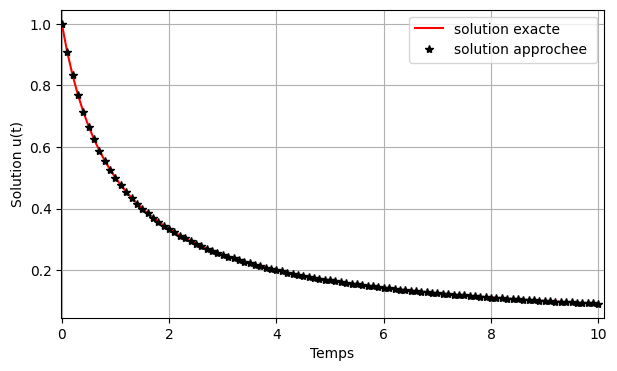

In [98]:
# Création d'un objet "param" issu de la classe Param() :
param = Param()

# Spécification des paramètres de la simulation
param.u0 = 1.
param.a = 1.
param.T = 10.
param.n = 100
param.dt = param.T / param.n
param.function = quadra
param.exact = sol_ex_quad
param.schema = CrankNicolson

print("nombre pas de temps : ", param.n)

# Appel des fonctions python
tabtemps(param)
calcul_solution_exacte(param)
param.schema(param)

# Appel de la fonction "graphique" en passant comme argument l'objet "param"
graphique(param)

**5)** Calculer l'ordre de convergence de la méthode de Crank-Nicolson par regression linéaire. Vous vous servirez pour cela de la fonction `OrdreConv` (implémentée lors du TP précédent et donnée ci-dessus) après avoir construit le tableau des **erreurs** et celui du nombre d'**itérations**.

## Questions Partie B : Méthode de Heun

Le but de cette partie est d'implémenter la méthode de Heun. D'après le cours, on sait que le schéma de Heun s'écrit comme suit :

$$
\displaystyle   u^{n+1} =  \displaystyle{{ 1}\over{2 }}\big( \underbrace{u^n  + \Delta t \,f(u^n)}_{{\widetilde u_1}\,^{n+1}}\big) + \displaystyle{{ 1}\over{2 }}\big( \underbrace{u^n  +  \Delta t \,f( \ {\widetilde u_1}\,^{n+1})}_{{\widetilde u_2}\,^{n+1}}\big) 
$$

**6)** 
* Compléter la fonction Python `Heun` ci-dessous.    
* Tester votre fonction `Heun` dans le cas quadratique ($f(u) = -a \ u^2$, avec $a=1$ et $u_0 = 1$)  
* Représenter sur un même graphique la solution numérique obtenue ainsi que la solution exacte (appel de la fonction `graphique`).  
* Calculer l'ordre de convergence de la méthode de Heun par regression linéaire.

In [99]:
def Heun(param) :
    u0 = param.u0
    dt = param.dt
    n = param.n

    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u1_tilde = u[i] + dt * param.function(u[i], param)
        u[i+1] = u[i] + dt / 2 * (param.function(u[i], param) + param.function(u1_tilde, param))
    param.solution_approchee = u

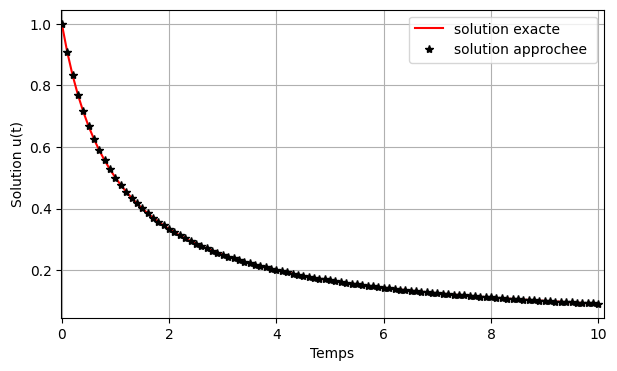

In [100]:
# Test de Heun dans le cas quadratique
param = Param()
param.u0 = 1.
param.a = 1.
param.T = 10.
param.n = 100
param.dt = param.T / param.n
param.function = quadra
param.exact = sol_ex_quad
param.schema = Heun

tabtemps(param)
calcul_solution_exacte(param)
param.schema(param)
graphique(param)

Ordre de convergence de Heun : 2.0136182768057997


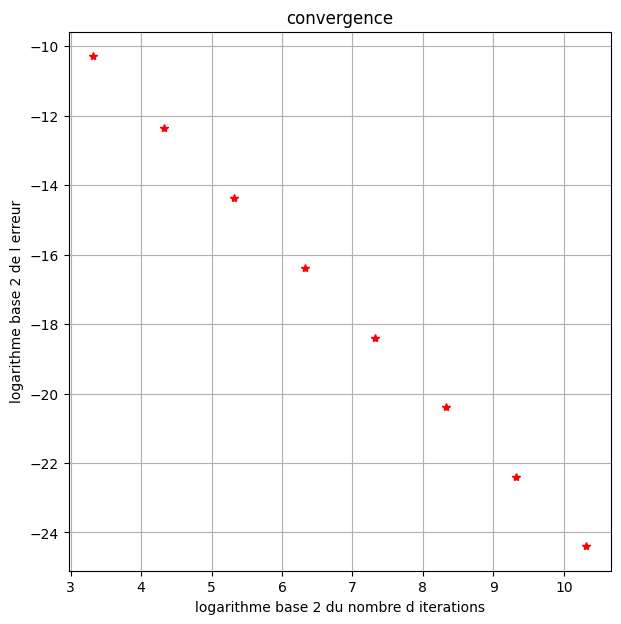

In [101]:
# Calcul de l'ordre de convergence de Heun
nb_sim = 8
err = np.zeros(nb_sim)
ite = np.zeros(nb_sim)

for k in range(nb_sim) :
    param = Param()
    param.u0 = 1.
    param.a = 1.
    param.T = 1.
    param.n = 10 * 2**k
    param.dt = param.T / param.n
    param.function = quadra
    param.exact = sol_ex_quad
    param.schema = Heun

    tabtemps(param)
    calcul_solution_exacte(param)
    param.schema(param)

    err[k] = np.max(np.abs(param.solution_exacte - param.solution_approchee))
    ite[k] = param.n

PlotConv(ite, err)
print("Ordre de convergence de Heun :", OrdreConv(ite, err))

## Questions Partie C : Bilan final des 4 méthodes (Euler explicite, Euler implicite, Crank-Nicolson, Heun)

Le but de cette partie est de comparer graphiquement les 4 méthodes.

**7)** Tracer sur un même graphique la solution exacte ainsi que **les solutions numériques** obtenues avec les 4 méthodes dans le cas **linéaire** ($f(u) = -a \ u$, avec $a=1$ et $u_0 = 1$).  
Vous vous servirez pour cela de la fonction `graphique4c` déjà implémentée et donnée ci-dessous.

In [104]:
def graphique4c(u_Eul_ex, u_Eul_imp, u_Crank, u_Heun, param) :
    
    '''
    Fonction permettant de tracer sur un même graphique 
    la solution exacte et les solutions issues des 4 methodes numeriques.
        @ u_Eul_ex : tableau numpy de la solution u pour le schéma d'Euler explicite
        @ u_Eul_imp : tableau numpy de la solution u pour le schéma d'Euler implicite
        @ u_Crank : tableau numpy de la solution u pour le schéma de Crank Nicolson
        @ u_Heun : tableau numpy de la solution u pour le schéma de Heun
    '''
    
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_xlim(-.01, param.T+0.1)

    ax.plot (param.t, param.solution_exacte, 'r--', label='solution exacte ')
    ax.plot (param.t, u_Eul_ex, color='blue', marker='*' , lw=0, label='Euler Explicite ')
    ax.plot (param.t, u_Eul_imp, color='orange', marker='*' , lw=0, label='Euler Implicite ')
    ax.plot (param.t, u_Crank, color='green', marker='*' , lw=0, label='Crank Nicolson ')
    ax.plot (param.t, u_Heun, color='purple', marker='*' , lw=0, label='Heun ')

    plt.xlabel('Time')
    plt.ylabel('Solution u(t)')
    ax.legend(loc='best')
    plt.grid(True)

    plt.draw()

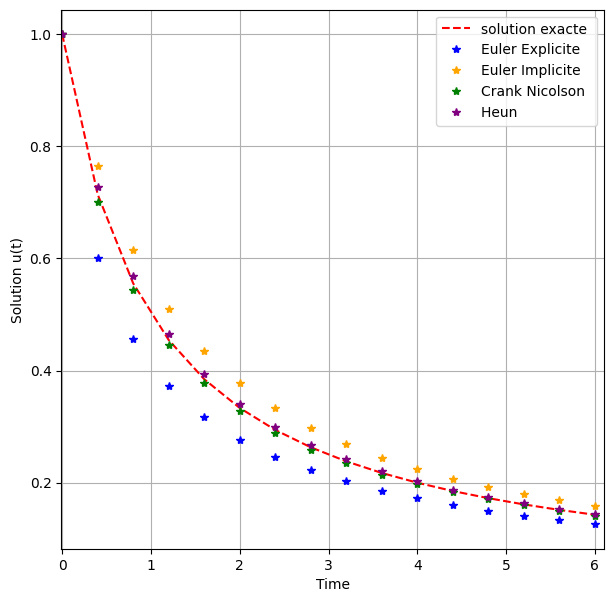

In [115]:
# Question 7 : Comparaison des 4 méthodes dans le cas linéaire
param = Param()
param.u0 = 1.
param.a = 1.
param.T = 6.
param.n = 15
param.dt = param.T / param.n
param.function = quadra
param.exact = sol_ex_quad

tabtemps(param)
calcul_solution_exacte(param)

# Euler Explicite
param.schema = EulerExplicite
param.schema(param)
u_Eul_ex = param.solution_approchee.copy()

# Euler Implicite
param.schema = EulerImplicite
param.schema(param)
u_Eul_imp = param.solution_approchee.copy()

# Crank-Nicolson
param.schema = CrankNicolson
param.schema(param)
u_Crank = param.solution_approchee.copy()

# Heun
param.schema = Heun
param.schema(param)
u_Heun = param.solution_approchee.copy()

graphique4c(u_Eul_ex, u_Eul_imp, u_Crank, u_Heun, param)

**8)** Tracer sur un même graphique **les courbes de convergence** des 4 méthodes (toujours dans le cas **linéaire** $f(u) = -a \ u$, avec $a=1$ et $u_0 = 1$).  
Vous vous servirez pour cela de la fonction `PlotConv4c` déjà implémentée et donnée ci-dessous.

In [103]:
def PlotConv4c(ite, errEE, errEI, errCN, errH) :

    '''
    Fonction permettant de tracer sur le même graphique 
    les courbes de convergence des 4 methodes numeriques.
        @ ite : tableau numpy des nombres d'iterations de chaque simulation
        @ errEE : tableau numpy des erreurs pour le schéma d'Euler explicite
        @ errEI : tableau numpy des erreurs pour le schéma d'Euler implicite
        @ errCN : tableau numpy des erreurs pour le schéma de Crank Nicolson
        @ errH : tableau numpy des erreurs pour le schéma de Heun
    '''
    
    # calcul des logarithmes base 2 des tableaux
    ite = np.log(ite) / np.log(2)
    errEE = np.log(errEE) / np.log(2)
    errEI = np.log(errEI) / np.log(2)
    errCN = np.log(errCN) / np.log(2)
    errH = np.log(errH) / np.log(2)
    
    # tracé des 4 courbes de convergence
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title( 'convergence' ) 
    ax.set_xlabel('logarithme base 2 du nombre de pas de temps')
    ax.set_ylabel('logarithme base 2 de l erreur')
    ax.plot (ite, errEE, color='blue',marker='*',label='Euler Explicite ')   
    ax.plot (ite, errEI, color='orange',marker='*',label='Euler Implicite ')   
    ax.plot (ite, errCN, color='green',marker='*',label='Crank Nicolson ')   
    ax.plot (ite, errH, color='purple',marker='*',label='Heun ')   
    ax.legend(loc='best')
    plt.grid(True)
    plt.draw()
    
    return

Ordre Euler Explicite : 1.012853749132129
Ordre Euler Implicite : 0.9885681069848852
Ordre Crank-Nicolson  : 2.000672909086244
Ordre Heun            : 2.0136182768057997


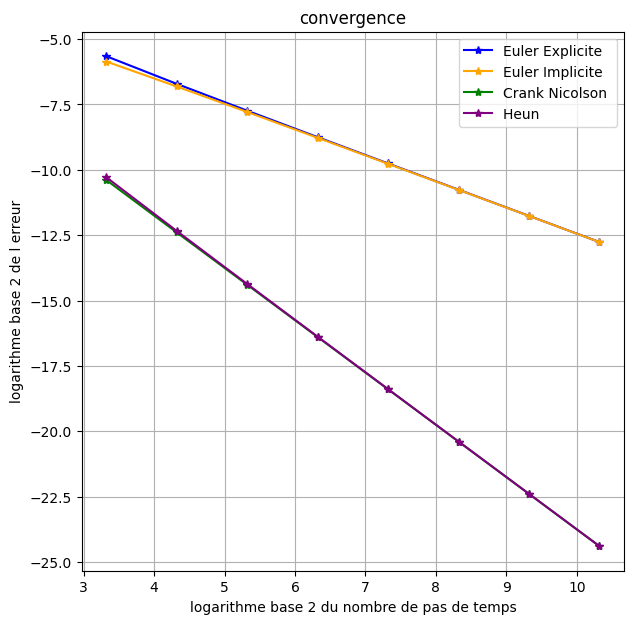

In [116]:
# Question 8 : Courbes de convergence des 4 méthodes (cas linéaire)
nb_sim = 8
errEE = np.zeros(nb_sim)
errEI = np.zeros(nb_sim)
errCN = np.zeros(nb_sim)
errH = np.zeros(nb_sim)
ite = np.zeros(nb_sim)

for k in range(nb_sim) :
    param = Param()
    param.u0 = 1.
    param.a = 1.
    param.T = 1.
    param.n = 10 * 2**k
    param.dt = param.T / param.n
    param.function = quadra
    param.exact = sol_ex_quad

    tabtemps(param)
    calcul_solution_exacte(param)

    # Euler Explicite
    EulerExplicite(param)
    errEE[k] = np.max(np.abs(param.solution_exacte - param.solution_approchee))

    # Euler Implicite
    EulerImplicite(param)
    errEI[k] = np.max(np.abs(param.solution_exacte - param.solution_approchee))

    # Crank-Nicolson
    CrankNicolson(param)
    errCN[k] = np.max(np.abs(param.solution_exacte - param.solution_approchee))

    # Heun
    Heun(param)
    errH[k] = np.max(np.abs(param.solution_exacte - param.solution_approchee))

    ite[k] = param.n

PlotConv4c(ite, errEE, errEI, errCN, errH)

print("Ordre Euler Explicite :", OrdreConv(ite, errEE))
print("Ordre Euler Implicite :", OrdreConv(ite, errEI))
print("Ordre Crank-Nicolson  :", OrdreConv(ite, errCN))
print("Ordre Heun            :", OrdreConv(ite, errH))
